# Positive Percentage by Session / Fold / Radius

This notebook reads the manifest CSV and visualizes positive patch percentage grouped by:
- session
- fold
- radius_km

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

Using manifest: E:\data\processed\norwegian_manifest.csv
Rows: 150
Sessions: 6
Folds: [0, 1, 2, 3, 4]


,session,fold,radius_km,total_positive,total_patches,n_rows,positive_pct
0,030326,0,1.0,0,33622,2,0.000000
1,030326,0,2.0,0,33622,2,0.000000
2,030326,0,3.0,19,33622,2,0.056511
3,030326,0,4.0,907,33622,2,2.697638
4,030326,0,5.0,10660,33622,2,31.705431
5,030326,0,6.0,11937,33622,2,35.503539
6,030326,0,7.0,13722,33622,2,40.812563
7,030326,0,8.0,14967,33622,2,44.515496
8,030326,0,9.0,15920,33622,2,47.349949
9,030326,0,10.0,16609,33622,2,49.399203


radius_km,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0
session_fold,,,,,,,,,,
030326 | fold 0,0.000000,0.000000,0.056511,2.697638,31.705431,35.503539,40.812563,44.515496,47.349949,49.399203
230226 | fold 1,0.000000,1.502217,3.011052,8.139766,36.028941,45.708424,50.129045,68.334326,69.488011,71.197582
260326_part1 | fold 2,0.105031,0.946562,3.364843,7.186956,12.036325,16.697408,23.163234,29.326775,34.546316,39.086997
260326_part2 | fold 2,0.000000,1.355241,5.135652,9.895555,14.948414,18.937715,24.790473,29.970704,33.591899,36.703605
280126 | fold 3,0.127412,1.377260,3.304615,7.968289,23.344659,31.602152,35.653036,46.234276,46.950208,47.929054
300925 | fold 4,8.792561,18.111582,43.169698,60.460823,67.776562,73.882128,77.813483,80.377410,83.091754,85.532613



Fold 0 (rows=session, cols=radius)


radius_km,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0
session,,,,,,,,,,
030326,0.0,0.0,0.056511,2.697638,31.705431,35.503539,40.812563,44.515496,47.349949,49.399203


...

radius_km,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0
session,,,,,,,,,,
260326_part1,0.105031,0.946562,3.364843,7.186956,12.036325,16.697408,23.163234,29.326775,34.546316,39.086997
260326_part2,0.000000,1.355241,5.135652,9.895555,14.948414,18.937715,24.790473,29.970704,33.591899,36.703605



Fold 3 (rows=session, cols=radius)


radius_km,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0
session,,,,,,,,,,
280126,0.127412,1.37726,3.304615,7.968289,23.344659,31.602152,35.653036,46.234276,46.950208,47.929054



Fold 4 (rows=session, cols=radius)


radius_km,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0
session,,,,,,,,,,
300925,8.792561,18.111582,43.169698,60.460823,67.776562,73.882128,77.813483,80.37741,83.091754,85.532613


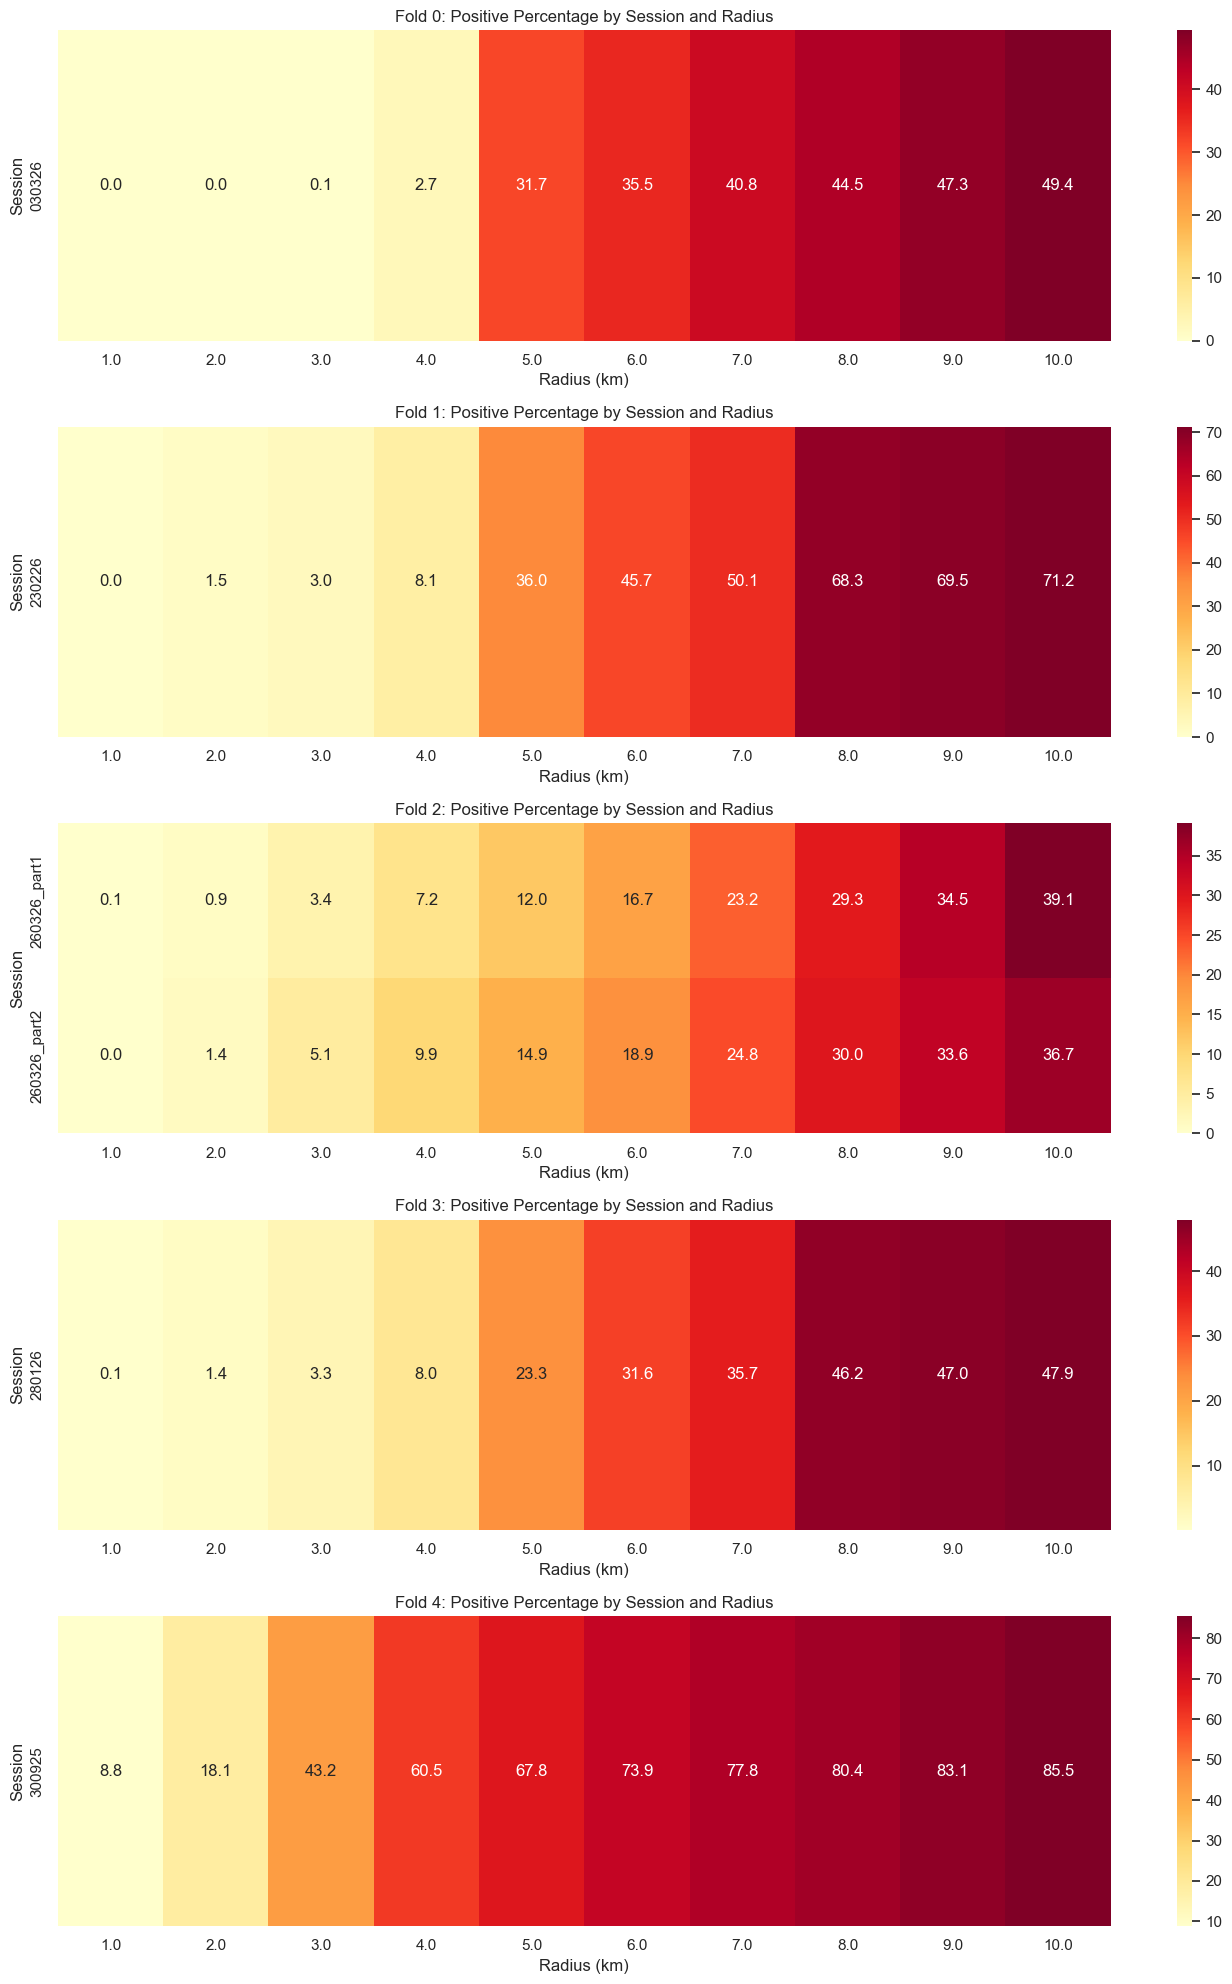

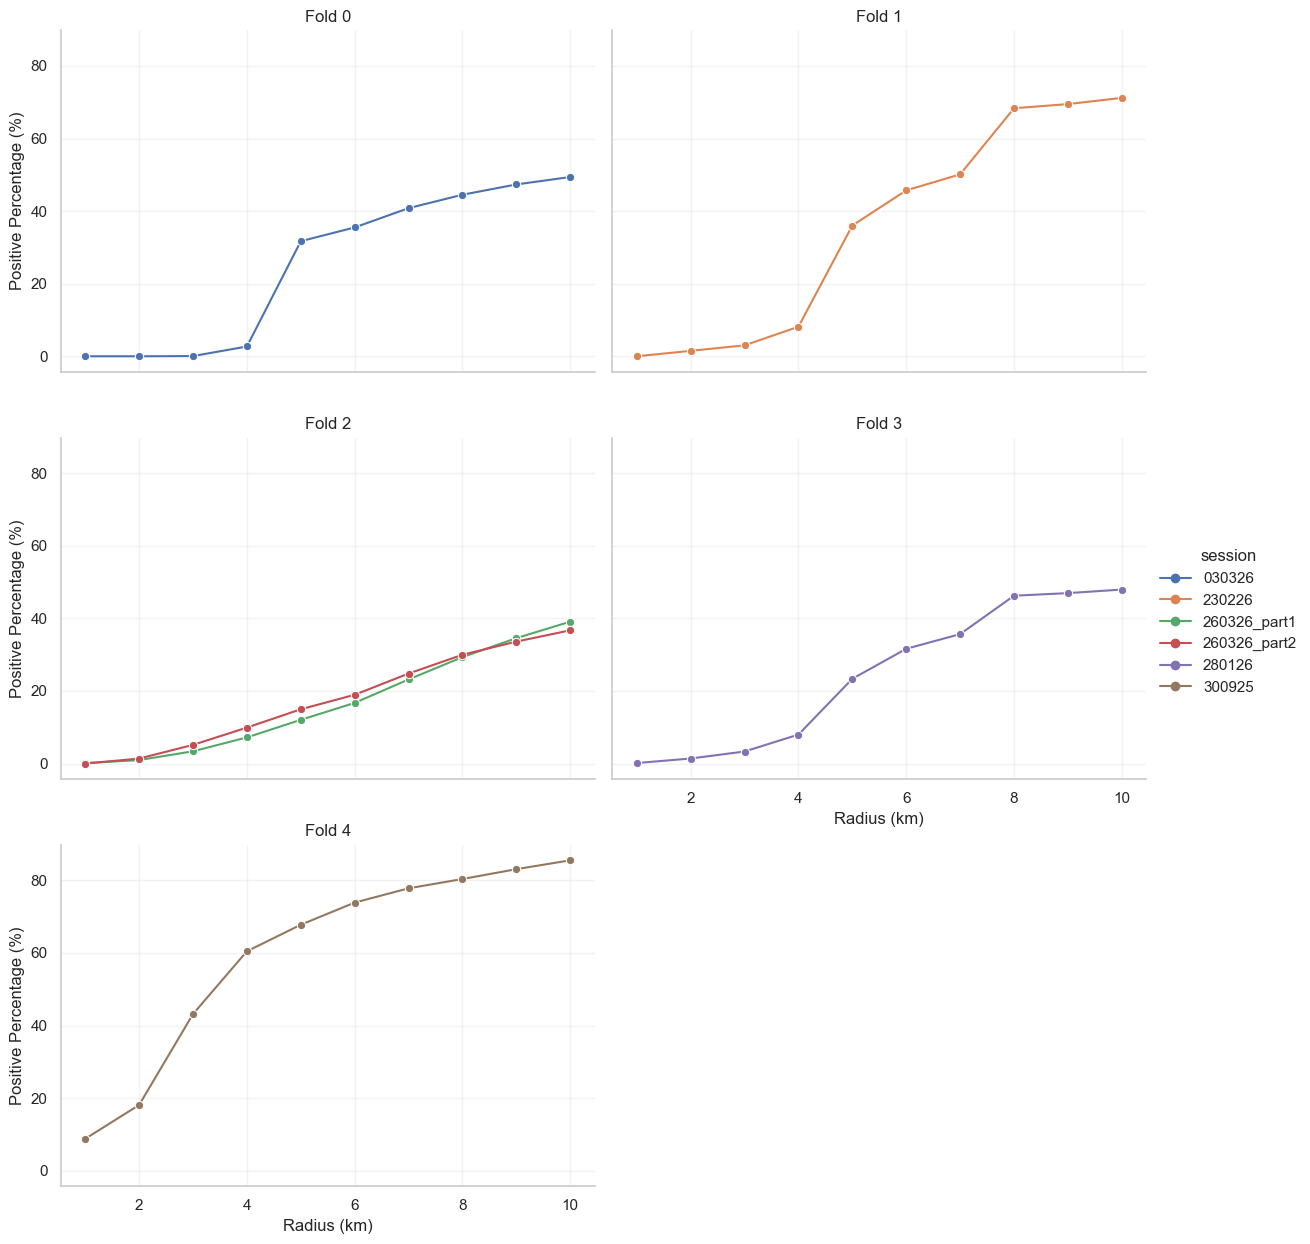

Saved: data\processed\norwegian_positive_pct_by_session_fold_radius.csv


In [8]:
from pathlib import Path
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Resolve manifest path across Windows / WSL / repo-relative locations
candidate_paths = [
    Path(r"E:/data/processed/norwegian_manifest.csv"),
    Path(r"/mnt/e/data/processed/norwegian_manifest.csv"),
    Path(r"data/processed/norwegian_manifest.csv"),
]

manifest_path = next((p for p in candidate_paths if p.exists()), None)
if manifest_path is None:
    checked = ", ".join(str(p) for p in candidate_paths)
    raise FileNotFoundError(f"Could not find norwegian_manifest.csv. Checked: {checked}")

print(f"Using manifest: {manifest_path}")

df = pd.read_csv(manifest_path)

required_cols = [
    "session",
    "fold",
    "radius_km",
    "num_positive",
    "num_patches",
]
missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

df = df.copy()
df["fold"] = pd.to_numeric(df["fold"], errors="coerce").astype("Int64")
df["radius_km"] = pd.to_numeric(df["radius_km"], errors="coerce")
df["num_positive"] = pd.to_numeric(df["num_positive"], errors="coerce")
df["num_patches"] = pd.to_numeric(df["num_patches"], errors="coerce")
df = df.dropna(subset=["fold", "radius_km", "num_positive", "num_patches"])
df["positive_pct"] = 100.0 * df["num_positive"] / df["num_patches"].clip(lower=1)

print(f"Rows: {len(df)}")
print(f"Sessions: {df['session'].nunique()}")
print(f"Folds: {sorted(df['fold'].dropna().astype(int).unique().tolist())}")

summary = (
    df.groupby(["session", "fold", "radius_km"], as_index=False)
      .agg(
          total_positive=("num_positive", "sum"),
          total_patches=("num_patches", "sum"),
          n_rows=("num_patches", "size"),
      )
)
summary["positive_pct"] = 100.0 * summary["total_positive"] / summary["total_patches"].clip(lower=1)
summary = summary.sort_values(["fold", "session", "radius_km"]).reset_index(drop=True)
radius_order = sorted(summary["radius_km"].dropna().unique().tolist())

display(summary.head(20))

# Main table requested: rows=session+fold, columns=radius (ordered by radius)
summary["session_fold"] = summary["session"].astype(str) + " | fold " + summary["fold"].astype(int).astype(str)
session_radius = summary.pivot_table(
    index="session_fold",
    columns="radius_km",
    values="positive_pct",
    aggfunc="mean",
).reindex(columns=radius_order)
display(session_radius)

# Optional: same orientation per fold
folds = sorted(summary["fold"].dropna().astype(int).unique().tolist())
for fold in folds:
    print(f"\nFold {fold} (rows=session, cols=radius)")
    fold_table = summary[summary["fold"] == fold].pivot_table(
        index="session",
        columns="radius_km",
        values="positive_pct",
        aggfunc="mean",
    ).reindex(columns=radius_order)
    display(fold_table)

# Heatmap per fold (rows=session, columns=radius ordered)
n_folds = max(1, len(folds))
fig, axes = plt.subplots(n_folds, 1, figsize=(14, 4 * n_folds), squeeze=False)

for i, fold in enumerate(folds):
    ax = axes[i, 0]
    h = summary[summary["fold"] == fold].pivot_table(
        index="session",
        columns="radius_km",
        values="positive_pct",
        aggfunc="mean",
    ).reindex(columns=radius_order)
    sns.heatmap(h, annot=True, fmt=".1f", cmap="YlOrRd", ax=ax, cbar=True)
    ax.set_title(f"Fold {fold}: Positive Percentage by Session and Radius")
    ax.set_xlabel("Radius (km)")
    ax.set_ylabel("Session")

plt.tight_layout()
plt.show()

# Line plots per fold
g = sns.relplot(
    data=summary,
    x="radius_km",
    y="positive_pct",
    hue="session",
    col="fold",
    kind="line",
    marker="o",
    col_wrap=2,
    height=4.2,
    aspect=1.4,
    facet_kws={"sharey": True, "sharex": True},
)
g.set_axis_labels("Radius (km)", "Positive Percentage (%)")
g.set_titles("Fold {col_name}")
for ax in g.axes.flat:
    ax.grid(True, alpha=0.25)
plt.show()

# Optional export
out_csv = Path("data/processed/norwegian_positive_pct_by_session_fold_radius.csv")
out_csv.parent.mkdir(parents=True, exist_ok=True)
summary.to_csv(out_csv, index=False)
print(f"Saved: {out_csv}")